In [1]:
from pathlib import Path
PROJECT_FOLDER = Path.cwd().parents[1]

import yaml
with open('config.yaml', 'r', encoding='utf-8') as f: 
    config = yaml.safe_load(f)

import sys, os
sys.path.append(PROJECT_FOLDER)
os.chdir(PROJECT_FOLDER)

print(sys.path[-1])
print(config)

/Users/sam/NUS/NUSC-ISC-FootballAnalysis
{'experiment_name': 'ex05_field_masking', 'gaussian_heatmap_model': 'wandb_logs/ISC-Football/qg4kdwvl/checkpoints/epoch=31-step=896.ckpt', 'pitch_cover_model': 'wandb_logs/ISC-Football/m4aiqdug/checkpoints/epoch=31-step=384.ckpt', 'pitch_calibration_dataset': {'img_folder': 'data/calibration', 'n_limit': 128, 'width': 640, 'height': 360, 'centered': False, 'keypoint_only': False, 'in_channels': 3}, 'pitch_calibration_datamodule': {'batch_size': 8, 'num_workers': 8, 'persistent_workers': True}, 'spiideo_dataset': {'base_folder': 'data/SpiideoSynLoc', 'n_limit': 32, 'width': 3840, 'height': 2160, 'n_crops': 32, 'crop_width': 960, 'crop_height': 540, 'crop_export_width': 320, 'crop_export_height': 180, 'sigma': 8, 'oversampling_rate': 16.0, 'in_channels': 3}, 'spiideo_datamodule': {'batch_size': 8, 'num_workers': 10, 'persistent_workers': True}, 'trainer': {'accelerator': 'gpu', 'max_epochs': 32}}


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from dataobjects.pitch import Pitch, PitchKeypointMapping

from datamodules.calibration.field_pitch import PitchCalibrationDataModule, PitchCalibrationDatasetArgs, PitchCalibrationDataModule
from datamodules.calibration.field_cover import CoverCalibrationDataModule, CoverCalibrationDatasetArgs, CoverCalibrationDataModule
from datamodules.base_datamodule import BaseDataModuleArgs
from datamodules.spiideo import SpiideoWithMetadataDataModule, SpiideoDatasetArgs
from datamodules.calibration.calibration import CalibrationDataModule, CalibrationDatasetArgs
from datamodules.base_datamodule import BaseDataModuleArgs

from models.field_registration import Segmentation

spiideo_data_module = SpiideoWithMetadataDataModule(
    SpiideoDatasetArgs(**config['spiideo_dataset']), 
    BaseDataModuleArgs(**config['spiideo_datamodule'])
)


/Users/sam/miniconda3/envs/ISC-Football/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
pitch_calibration_datamodule = PitchCalibrationDataModule(
    PitchCalibrationDatasetArgs(**config['pitch_calibration_dataset']),
    BaseDataModuleArgs(**config['pitch_calibration_datamodule'])
)

In [4]:
pitch_cover_calibration_datamodule = CoverCalibrationDataModule(
    CoverCalibrationDatasetArgs(**config['pitch_calibration_dataset']),
    BaseDataModuleArgs(**config['pitch_calibration_datamodule'])
)

In [5]:
train_ds = pitch_cover_calibration_datamodule.dataset('train')
print(f'Selected images: {len(train_ds)}')

128 JPEG images imported
Selected images: 96


/var/folders/sb/bsmqpwg91sn_3fvr5z519y5c0000gn/T/ipykernel_34393/3097893591.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


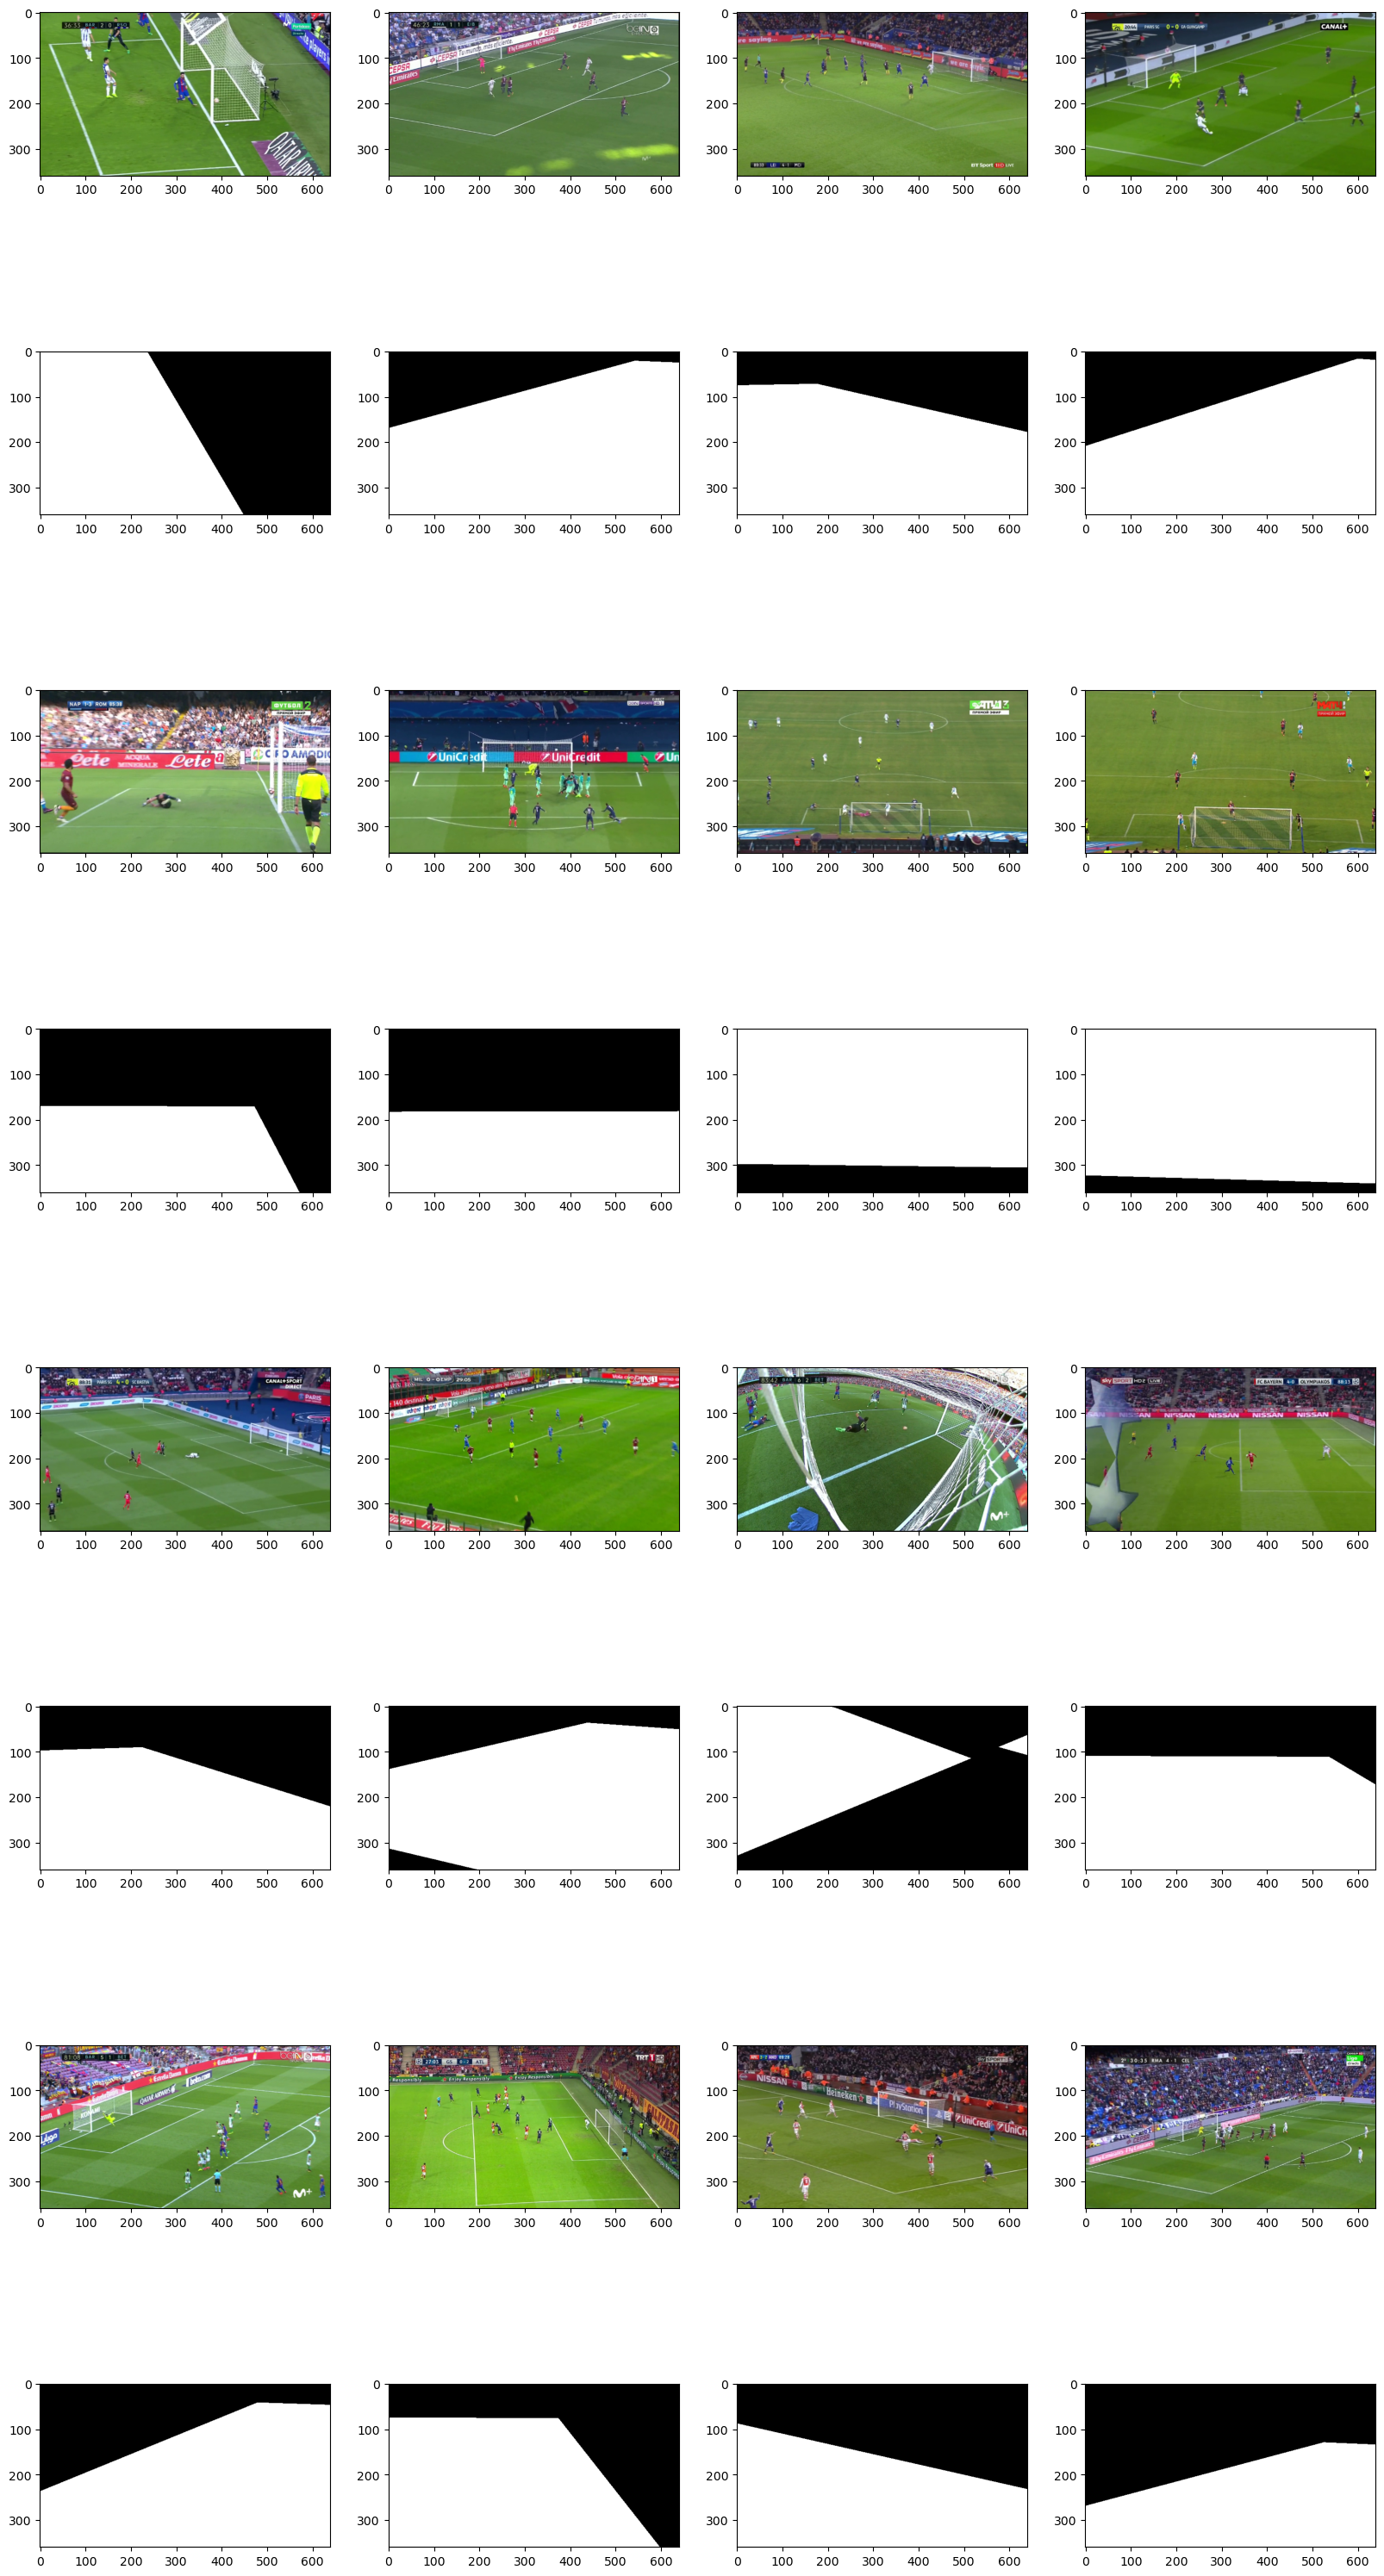

In [6]:
fig, ax = plt.subplots(ncols=4, nrows=8, figsize=(20, 40))

for idx in range(16):
    img, field_mask = train_ds[idx]
    ax[2 * (idx // 4), idx % 4].imshow(img.permute((1, 2, 0)))
    ax[2 * (idx // 4) + 1, idx % 4].imshow(field_mask.permute((1, 2, 0)), cmap='gray')

fig.show()